# 🧠 Reconhecimento Facial com Transfer Learning

Este projeto tem como objetivo aplicar **Transfer Learning** para realizar o **reconhecimento facial de múltiplos rostos em uma única imagem**, utilizando um **modelo de deep learning pré-treinado**.

## 👥 Objetivo Específico

Reconhecer os rostos de **Elon Musk**, **Sam Altman** e **Lidiane Jones** em uma mesma imagem de teste, utilizando um banco de dados personalizado com imagens de referência para cada pessoa.

## 🎯 Desafio

O desafio consiste em:

- Utilizar um modelo pré-treinado de reconhecimento facial (neste projeto, o **VGG-Face** via biblioteca `DeepFace`)
- Aplicar **Transfer Learning** para adaptar o modelo ao nosso banco de rostos personalizado
- Detectar **múltiplos rostos** em uma imagem de teste
- Realizar o **reconhecimento facial** desses rostos
- Exibir a imagem com **bounding boxes** e os **nomes identificados**

## 🗂️ Estrutura do Projeto

- `faces_db/`: pasta contendo subpastas com imagens de referência para cada pessoa
- `test_1/test_1.png`: imagem de teste com múltiplos rostos
- Notebook em Python (Google Colab) para processamento e visualização

## 🧪 Tecnologias Utilizadas

- `DeepFace`: biblioteca para reconhecimento facial com modelos pré-treinados
- `VGG-Face`: modelo de deep learning usado para extração de embeddings
- `OpenCV`: para exibição de bounding boxes e nomes
- `Google Drive`: para armazenamento e acesso aos dados

---

Este projeto demonstra como adaptar modelos avançados de visão computacional para tarefas específicas com poucos dados, utilizando Transfer Learning de forma eficiente e prática.

In [2]:
# Montar o drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Instalar bibliotecas necessárias
!pip install deepface
!pip install opencv-python

# Importar bibliotecas principais
from deepface import DeepFace
import cv2
import os
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [7]:
# Caminho para o banco de dados
db_path = '/content/drive/MyDrive/face_detection/faces_db'

# Criar listas para armazenar os embeddings e os nomes
embeddings = []
names = []

# Percorrer as pastas no banco de dados
for person in os.listdir(db_path):
    person_folder = os.path.join(db_path, person)
    if os.path.isdir(person_folder):
        for image_name in os.listdir(person_folder):
            image_path = os.path.join(person_folder, image_name)
            try:
                # Extrair o embedding com Deepface
                representation = DeepFace.represent(img_path=image_path, model_name='VGG-Face', enforce_detection=False)
                embedding = representation[0]['embedding']
                embeddings.append(embedding)
                names.append(person)
            except Exception as e:
                print(f"Erro ao processar imagem {image_path}: {e}")

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5


25-09-02 12:10:45 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


100%|██████████| 580M/580M [00:02<00:00, 219MB/s]


In [11]:
from scipy.spatial.distance import cosine

# Caminho da imagem de teste
test_img_path = "/content/drive/MyDrive/face_detection/test_1/test_1.png"

# Extrair embedding da imagem de teste
try:
    test_representation = DeepFace.represent(img_path=test_img_path, model_name="VGG-Face", enforce_detection=False)
    test_embedding = test_representation[0]["embedding"]
except Exception as e:
    print(f"Erro ao processar imagem de teste: {e}")
    test_embedding = None

# Comparar com os embeddings do banco
if test_embedding:
    min_distance = float("inf")
    identity = "Desconhecido"

    for i, db_embedding in enumerate(embeddings):
        distance = cosine(test_embedding, db_embedding)

        if distance < min_distance:
            min_distance = distance
            identity = names[i]

    # Definir um limite de confiança (ajustável)
    threshold = 0.4

    if min_distance < threshold:
        print(f"✅ Rosto reconhecido: {identity} (distância: {min_distance:.4f})")
    else:
        print(f"❌ Rosto não reconhecido. Distância mínima: {min_distance:.4f}")

✅ Rosto reconhecido: elon_musk (distância: 0.3114)


25-09-02 12:59:52 - Found 0 newly added image(s), 0 removed image(s), 30 replaced image(s).


Finding representations: 100%|██████████| 30/30 [00:57<00:00,  1.91s/it]


25-09-02 13:00:49 - There are now 32 representations in ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl
25-09-02 13:00:49 - Searching /content/temp_face.png in 32 length datastore
25-09-02 13:00:50 - find function duration 58.31201481819153 seconds
25-09-02 13:00:50 - Found 0 newly added image(s), 0 removed image(s), 30 replaced image(s).


Finding representations: 100%|██████████| 30/30 [00:58<00:00,  1.95s/it]


25-09-02 13:01:48 - There are now 32 representations in ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl
25-09-02 13:01:49 - Searching /content/temp_face.png in 32 length datastore
25-09-02 13:01:49 - find function duration 59.345003604888916 seconds
25-09-02 13:01:49 - Found 0 newly added image(s), 0 removed image(s), 30 replaced image(s).


Finding representations: 100%|██████████| 30/30 [00:57<00:00,  1.93s/it]


25-09-02 13:02:47 - There are now 32 representations in ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl
25-09-02 13:02:48 - Searching /content/temp_face.png in 32 length datastore
25-09-02 13:02:48 - find function duration 59.049851417541504 seconds


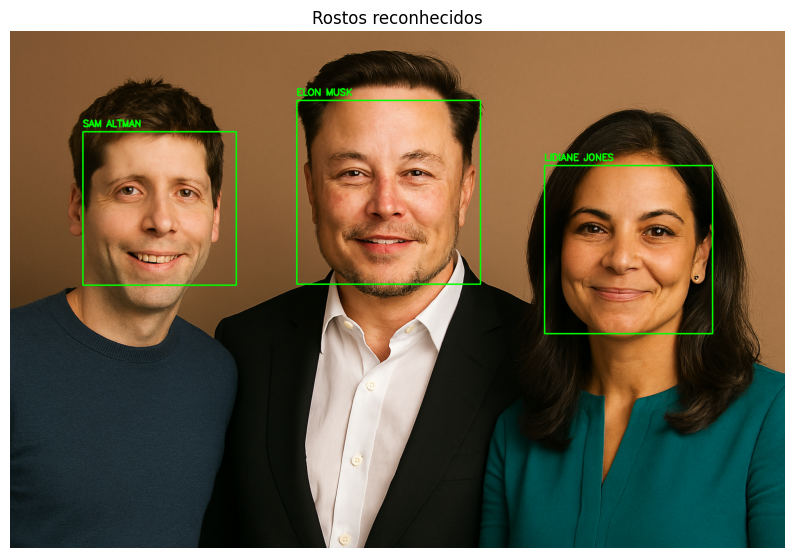

In [19]:
# Caminho da imagem de teste
test_img_path = "/content/drive/MyDrive/face_detection/test_1/test_1.png"

# Carregar a imagem
img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Dicionário de nomes reais (prefixo → nome completo)
nome_real = {
    "sam": "SAM ALTMAN",
    "elon": "ELON MUSK",
    "lidiane": "LIDIANE JONES"
}

# Detectar todos os rostos na imagem
faces = DeepFace.extract_faces(
    img_path=test_img_path,
    detector_backend='opencv',
    enforce_detection=False,
    align=False
)

# Loop pelos rostos detectados
for face in faces:
    # Extrair coordenadas da bounding box
    area = face['facial_area']
    x, y, w, h = area['x'], area['y'], area['w'], area['h']

    # Corrigir tipo da imagem (de float64 para uint8)
    face_img = (face['face'] * 255).astype("uint8")

    # Salvar temporariamente o rosto para busca
    temp_path = "/content/temp_face.png"
    cv2.imwrite(temp_path, cv2.cvtColor(face_img, cv2.COLOR_RGB2BGR))

    # Buscar no banco
    result = DeepFace.find(
        img_path=temp_path,
        db_path="/content/drive/MyDrive/face_detection/faces_db",
        enforce_detection=False,
        detector_backend='opencv',
        model_name='VGG-Face',
        distance_metric='cosine'
    )

    if not result[0].empty:
        # Pegar o melhor match
        best_match = result[0].iloc[0]
        file_name = os.path.splitext(os.path.basename(best_match['identity']))[0]

        # Extrair prefixo (ex: "sam" de "sam1")
        prefix = ''.join([c for c in file_name if not c.isdigit()])

        # Buscar nome real no dicionário
        identity_clean = nome_real.get(prefix.lower(), prefix.upper())

        # Desenhar caixa verde e nome em verde
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img_rgb, identity_clean, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Exibir imagem final
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Rostos reconhecidos")
plt.show()